In [3]:
pip install yfinance pandas numpy matplotlib


In [9]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [199]:
# Download stock data and % daily return from Jan 2020
Stock=['AAPL', 'ACN', 'ADBE', 'ADI', 'ADSK', 'AKAM', 'AMAT', 'AMD', 'ANET', 'APH', 'APP', 'AVGO', 'CDNS', 'CDW', 'CIEN', 'CRM', 'CRWD', 'CSCO', 'CTSH', 'DDOG', 'DELL', 'EPAM', 'FFIV', 'FICO', 'FSLR', 'FTNT', 'GDDY', 'GEN', 'GLW', 'HPE', 'HPQ', 'IBM', 'INTC', 'INTU', 'IT', 'JBL', 'KEYS', 'KLAC', 'LRCX', 'MCHP', 'MPWR', 'MSFT', 'MSI', 'MU', 'NOW', 'NTAP', 'NVDA', 'NXPI', 'ON', 'ORCL', 'PANW', 'PLTR', 'PTC', 'QCOM', 'ROP', 'SMCI', 'SNPS', 'STX', 'SWKS', 'TDY', 'TEL', 'TER', 'TRMB', 'TXN', 'TYL', 'VRSN', 'WDAY', 'WDC', 'ZBRA']
Data_df = yf.download(Stock, start="2022-01-01", auto_adjust=True)["Close"]
Return = Data_df.pct_change().dropna()
print(Return.head())

[*********************100%***********************]  69 of 69 completed


Ticker          AAPL       ACN      ADBE       ADI      ADSK      AKAM  \
Date                                                                     
2022-01-04 -0.012691 -0.007146 -0.018374 -0.009032 -0.019491 -0.004766   
2022-01-05 -0.026600 -0.017611 -0.071426 -0.015437 -0.049858 -0.012569   
2022-01-06 -0.016693 -0.048291 -0.000603  0.003182 -0.000795 -0.031174   
2022-01-07  0.000988 -0.019180 -0.006652 -0.026241 -0.006777 -0.011977   
2022-01-10  0.000117  0.006069  0.029626  0.009240  0.000267  0.019088   

Ticker          AMAT       AMD      ANET       APH  ...       TDY       TEL  \
Date                                                ...                       
2022-01-04 -0.009817 -0.038738 -0.025169  0.003121  ...  0.013366  0.019441   
2022-01-05 -0.029174 -0.057264 -0.039738 -0.019016  ... -0.042760 -0.020898   
2022-01-06  0.016912  0.000588 -0.003605  0.000822  ... -0.004756  0.005351   
2022-01-07 -0.035372 -0.031050 -0.024045 -0.036037  ... -0.011408 -0.018507   
2022-01

In [201]:
# Assign equal weights to each stocks and calculate the daily/annualised portfolio return
n = len(Stock)
weight = np.repeat(1/n, n)

daily_portfolio_return = Return.dot(weight)
Portfolio_return = (daily_portfolio_return.mean() * 252)
(Portfolio_return*100).round(4)

18.6822

In [203]:
# calculate daily/ annualised portfolio volatility
daily_portfolio_volatility = daily_portfolio_return.std()


cov_matrix = Return.cov()
portfolio_volatility = np.sqrt(weight.T @ cov_matrix @ weight)

(portfolio_volatility*100).round(4)

1.6512

In [205]:
# Assume risk-free rate = 4% - Calculate the sharpe ratio

risk_free_rate = 0.04

sharpe_ratio = (Portfolio_return-risk_free_rate)/portfolio_volatility
sharpe_ratio

8.89193299464052

In [207]:
# Risk contribution per stock


marginal_contribution = cov_matrix @ weight
risk_contribution = (weight * marginal_contribution) / portfolio_volatility


risk_contribution_df = pd.DataFrame({
    "Stock": Return.columns,
    "Risk_Contribution": risk_contribution,
    "Percent_Contribution": risk_contribution / (risk_contribution.sum())
}).sort_values("Percent_Contribution", ascending=False)

risk_contribution_df

,Stock,Risk_Contribution,Percent_Contribution
Ticker,,,
APP,APP,0.000406,0.024583
MPWR,MPWR,0.000406,0.024558
SMCI,SMCI,0.000387,0.023450
PLTR,PLTR,0.000376,0.022758
NVDA,NVDA,0.000373,0.022584
...,...,...,...
GEN,GEN,0.000128,0.007739
VRSN,VRSN,0.000115,0.006964
ROP,ROP,0.000110,0.006644


In [209]:
print("Portfolio Volatility:", portfolio_volatility.round(4))
print("Sum Risk Contribution:", risk_contribution.sum().round(4))

Portfolio Volatility: 0.0165
Sum Risk Contribution: 0.0165


In [211]:
# Calculate Max Drawdown

cumulative_return = (1 + daily_portfolio_return).cumprod()
running_max = cumulative_return.cummax()
drawdown = cumulative_return/running_max - 1

max_drawdown =  drawdown.min()
max_drawdown

-0.32736790601044274

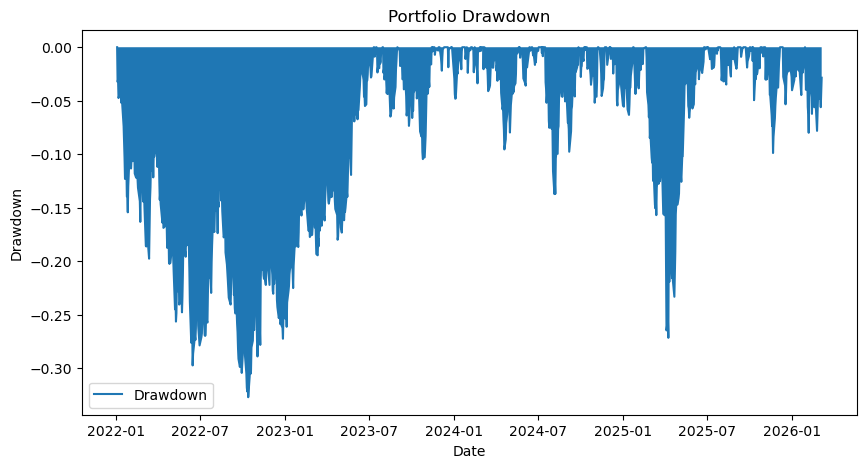

In [215]:
plt.figure(figsize=(10,5))
plt.plot(drawdown, label="Drawdown")
plt.fill_between(drawdown.index, drawdown, 0)
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.show()

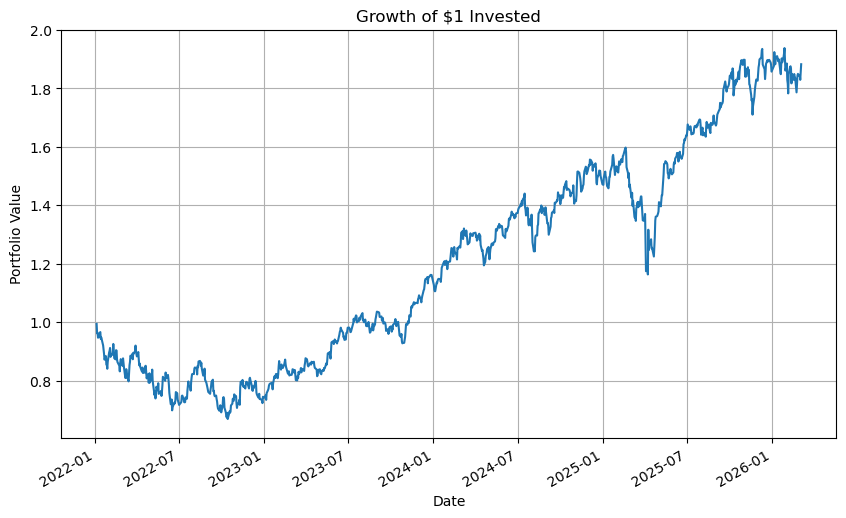

In [216]:
# Growth chart

growth = (1 + daily_portfolio_return).cumprod()

growth.plot(figsize=(10,6), title="Growth of $1 Invested")
plt.ylabel("Portfolio Value")
plt.grid(True)

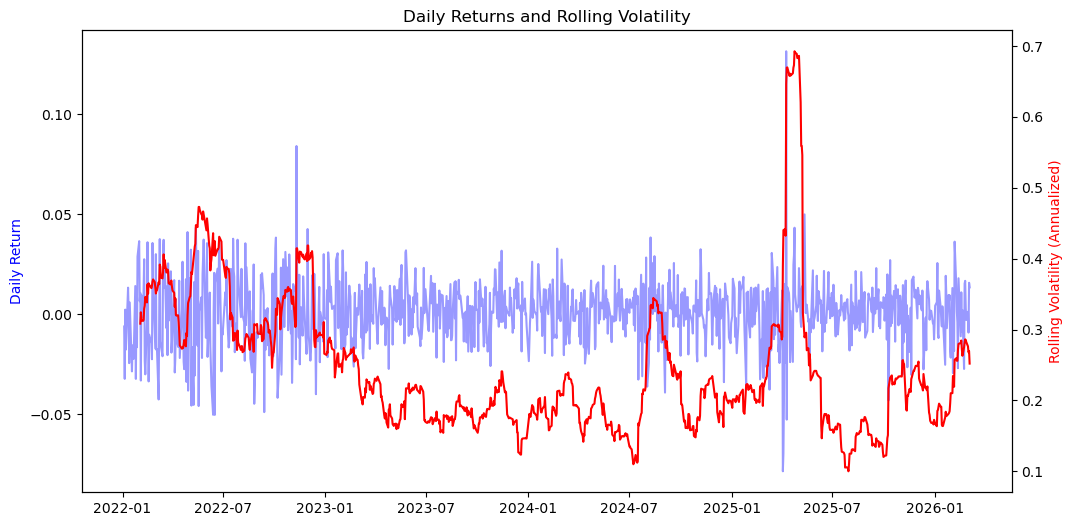

In [218]:
# plot daily portfolio return and volatility

rolling_vol = daily_portfolio_return.rolling(21).std() * np.sqrt(252)

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(daily_portfolio_return, color="blue", alpha=0.4)
ax1.set_ylabel("Daily Return", color="blue")

ax2 = ax1.twinx()
ax2.plot(rolling_vol, color="red")
ax2.set_ylabel("Rolling Volatility (Annualized)", color="red")

plt.title("Daily Returns and Rolling Volatility")
plt.show()